# **Import Required Libraries**

Before starting the analysis, we import all the required packages.
- Pandas → Reading and manipulating datasets.
- NumPy → Numerical computations.
- Matplotlib → Basic visualizations.
- Seaborn → Statistical plots with attractive styling.
- Plotly → Interactive visualizations.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(12,6)

# **Load the Datasets**

The project consists of multiple datasets, each representing a different aspect of the mutual fund industry.

In [2]:
fund_master = pd.read_csv("fund_master.csv")

nav = pd.read_csv("nav_history.csv")

aum = pd.read_csv("aum_by_fund_house.csv")

sip = pd.read_csv("monthly_sip_inflows.csv")

category = pd.read_csv("category_inflows.csv")

folios = pd.read_csv("industry_folio_count.csv")

investor = pd.read_csv("investor_transactions.csv")

performance = pd.read_csv("scheme_performance.csv")

portfolio = pd.read_csv("portfolio_holdings.csv")

# **Data Cleaning**

Raw datasets often contain missing values, incorrect data types, duplicate records, and formatting inconsistencies.

Cleaning ensures that the analysis is reliable and accurate.

The cleaning process includes:
- Converting date columns
- Removing duplicates
- Handling missing values
- Standardizing column names

In [3]:
nav["date"]=pd.to_datetime(nav["date"])

aum["date"]=pd.to_datetime(aum["date"])

sip["month"]=pd.to_datetime(sip["month"])

folios["month"]=pd.to_datetime(folios["month"])

category["month"]=pd.to_datetime(category["month"])

investor["transaction_date"]=pd.to_datetime(investor["transaction_date"])

# **Merge Datasets**

The NAV dataset only contains AMFI codes.

To understand which scheme each NAV belongs to, we merge the NAV history with the master dataset.

This allows us to analyze NAV using scheme names and categories.

In [4]:
nav_df = nav.merge(fund_master,on="amfi_code", how="left")

print(nav_df.head(5))

   amfi_code       date      nav       fund_house  \
0     119551 2022-01-03  54.3856  SBI Mutual Fund   
1     119551 2022-01-04  54.3474  SBI Mutual Fund   
2     119551 2022-01-05  54.6869  SBI Mutual Fund   
3     119551 2022-01-06  55.4550  SBI Mutual Fund   
4     119551 2022-01-07  55.3692  SBI Mutual Fund   

                                 scheme_name category sub_category     plan  \
0  SBI Bluechip Fund - Regular Plan - Growth   Equity    Large Cap  Regular   
1  SBI Bluechip Fund - Regular Plan - Growth   Equity    Large Cap  Regular   
2  SBI Bluechip Fund - Regular Plan - Growth   Equity    Large Cap  Regular   
3  SBI Bluechip Fund - Regular Plan - Growth   Equity    Large Cap  Regular   
4  SBI Bluechip Fund - Regular Plan - Growth   Equity    Large Cap  Regular   

  launch_date      benchmark  expense_ratio_pct  exit_load_pct  \
0  2006-02-14  NIFTY 100 TRI               1.54            1.0   
1  2006-02-14  NIFTY 100 TRI               1.54            1.0   
2  2006-



---



# **NAV Trend Analysis**

Analyze the daily movement of NAV for all 40 schemes between 2022 and 2026.

Highlight
- Bull Run (2023)
- Market Correction (2024)


In [5]:
fig = px.line(nav_df, x="date", y="nav",
              color="scheme_name",
              title="Daily NAV Trend for All 40 Mutual Fund Schemes (2022–2026")

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.2,
    annotation_text="Bull Run",
    annotation_position="top left"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.2,
    annotation_text="Market Correction",
    annotation_position="top left"
)

fig.show()



---



# **AUM Growth Analysis**

Analyze Assets Under Management (AUM) across major fund houses.

AUM indicates
- Investor confidence
- Fund popularity
- Market share
- Larger AUM generally indicates higher investor trust.

In [6]:
# Create a Year column
aum["year"] = aum["date"].dt.year


# Filter 2022–2025
aum = aum[(aum["year"] >= 2022) & (aum["year"] <= 2025)]

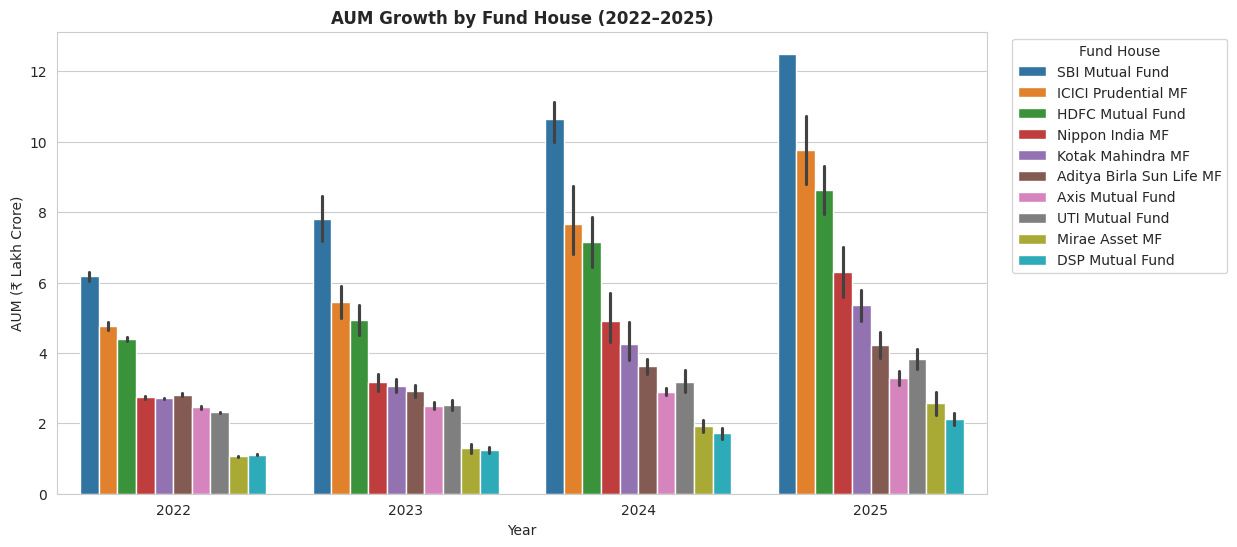

In [7]:
sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", weight="bold")
plt.xlabel("Year")
plt.ylabel("AUM (₹ Lakh Crore)")
plt.legend(title="Fund House", bbox_to_anchor=(1.02,1), loc="upper left")

plt.show()



---



# **Monthly SIP Inflow Trend**

Visualize monthly SIP investments.

In [8]:
fig = px.line (
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)"
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr ATH"
)

fig.show()



---



# **Category Wise Inflow Heatmap**

Compare monthly inflows across mutual fund categories.

This helps identify
- Popular investment categories
- Seasonal investment patterns
- Fund preferences

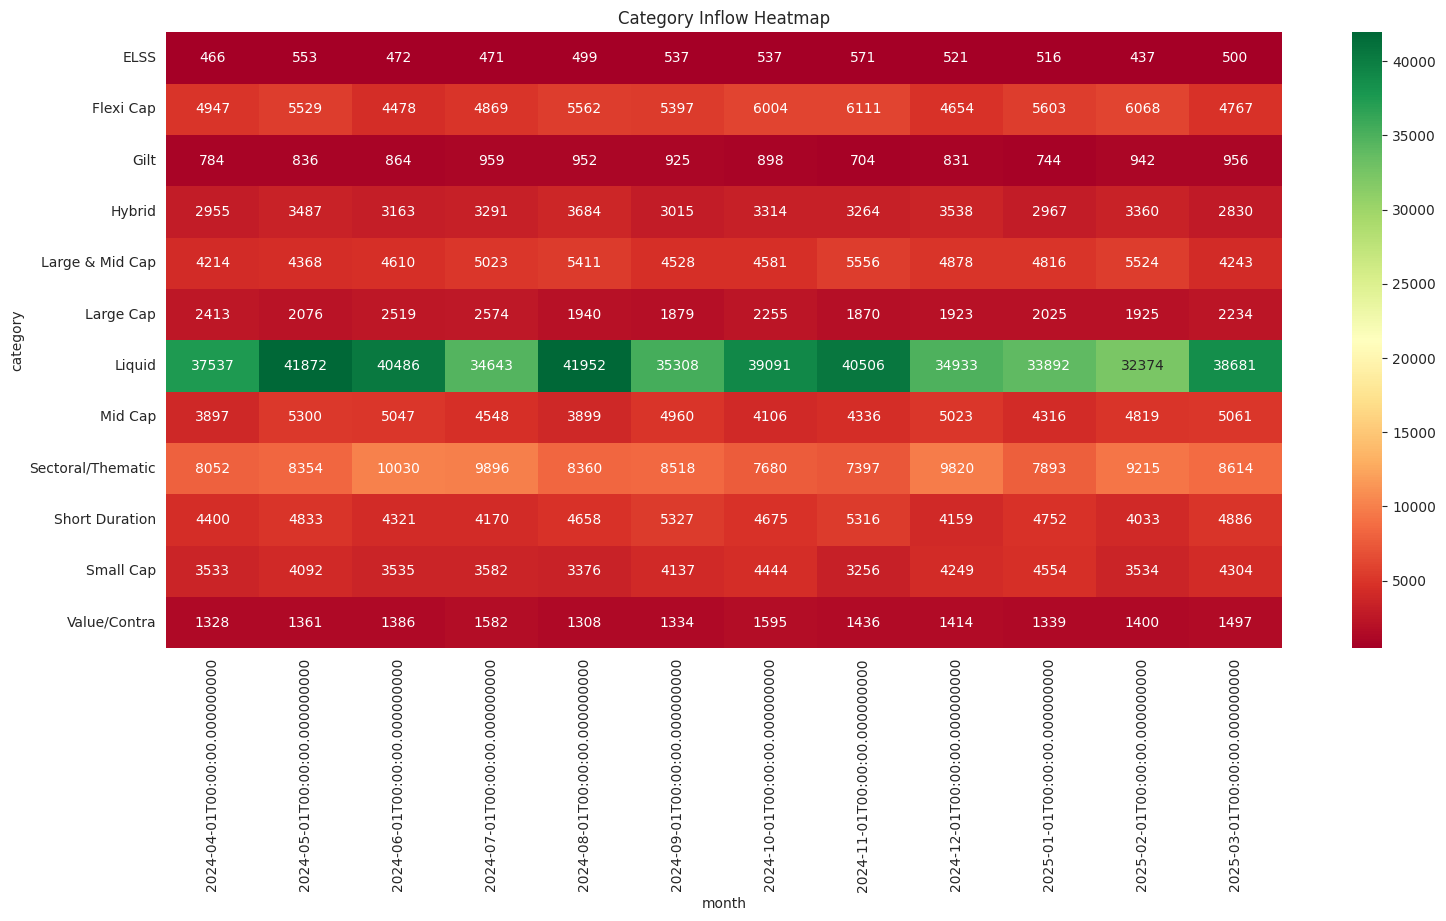

In [26]:
pivot = category.pivot (
    index = "category",
    columns = "month",
    values = "net_inflow_crore"
)

plt.figure(figsize=(18,8))

sns.heatmap(
    pivot,
    cmap="RdYlGn",
    annot=True,
    fmt=".0f"
)

plt.title("Category Inflow Heatmap")

plt.show()



---



# **Investor Demographics**

Study investor characteristics.

This includes
- Age Distribution
- Gender Distribution
- Investment Amount

## **Age Distribution**

Analyzed the distribution of investors across different age groups to understand which age segment participates the most in mutual fund investments.

Text(0.5, 1.0, 'Investor Age Distribution')

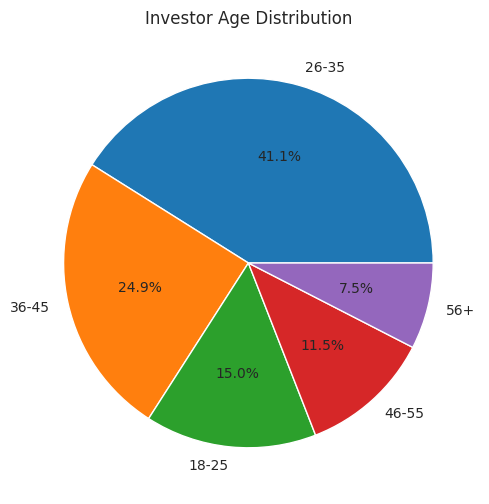

In [10]:
investor["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Investor Age Distribution")

## **SIP Amount by Age**

Analyzed the distribution of SIP investment amounts across different age groups using a box plot to compare investment behavior, spread, and variability among investors.

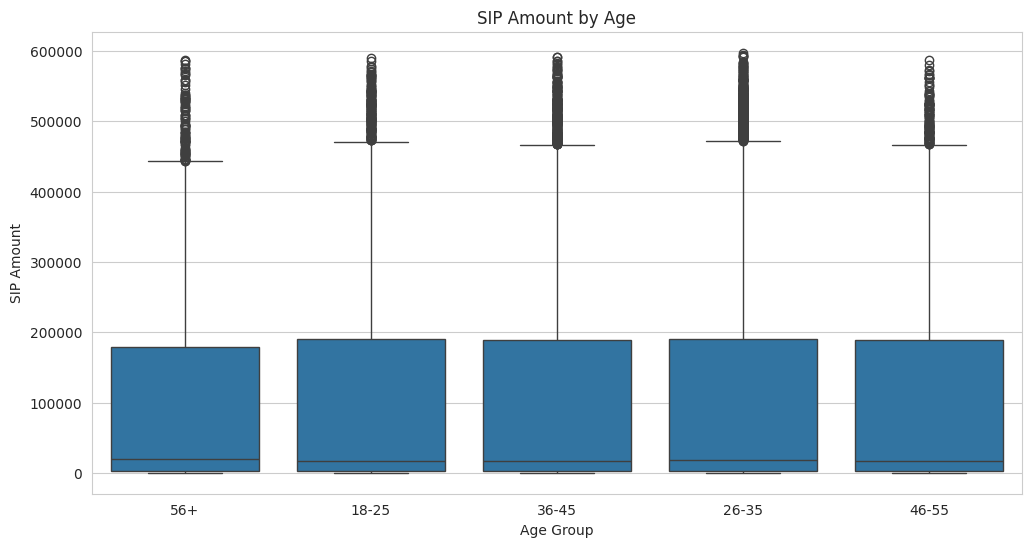

In [11]:
sns.boxplot(
    data = investor,
    x = "age_group",
    y = "amount_inr"
)

plt.title("SIP Amount by Age")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount")

plt.show()

## **Gender Split**

The analysis shows the share of male and female investors in the dataset, providing insights into investor diversity and helping identify opportunities to improve participation across different gender groups.

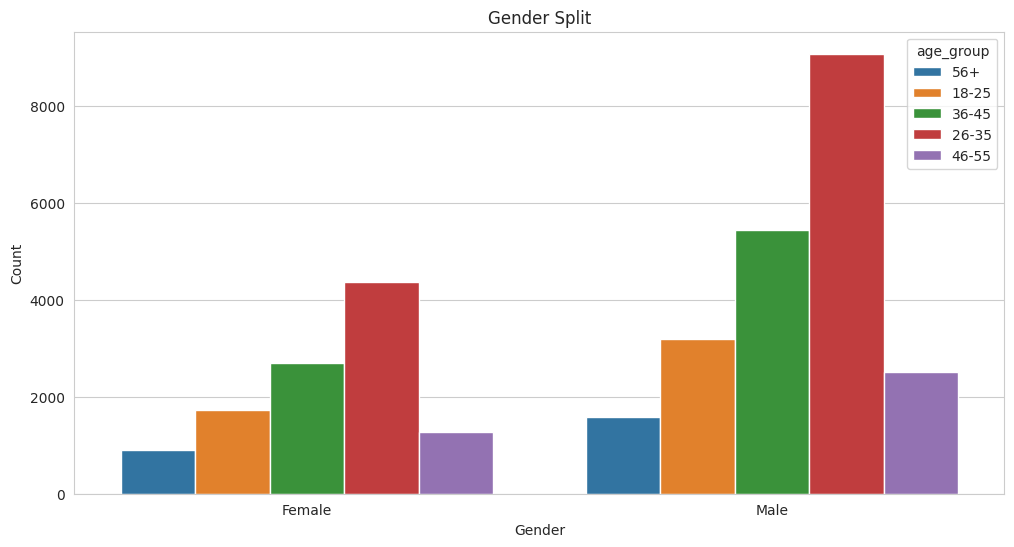

In [12]:
sns.countplot(
    data = investor,
    x = "gender",
    hue = "age_group"
)

plt.title("Gender Split")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()



---



# **Geographic distribution**

Analyzed the geographic distribution of mutual fund investments to identify which states and city tiers contribute the most to SIP investments across India.

## **State Wise SIP**

The analysis highlights the states with the highest total SIP investments, helping identify regions with strong investor participation and market potential.

Text(0.5, 1.0, 'Statewise SIP Distribution')

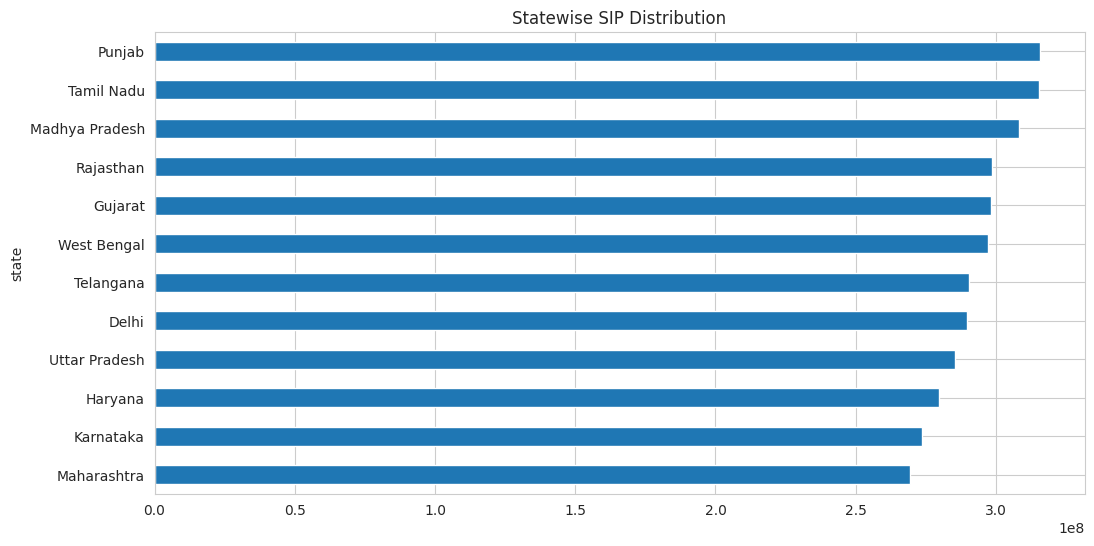

In [28]:
state=investor.groupby("state")["amount_inr"].sum().sort_values()

state.plot.barh()

plt.title("Statewise SIP Distribution")

## **T30 vs B30 City Tier**

The comparison between T30 and B30 cities shows the contribution of metropolitan and non-metropolitan regions, indicating the growing adoption of mutual fund investments beyond major cities.

Text(0.5, 1.0, 'T30 vs B30 City Tier')

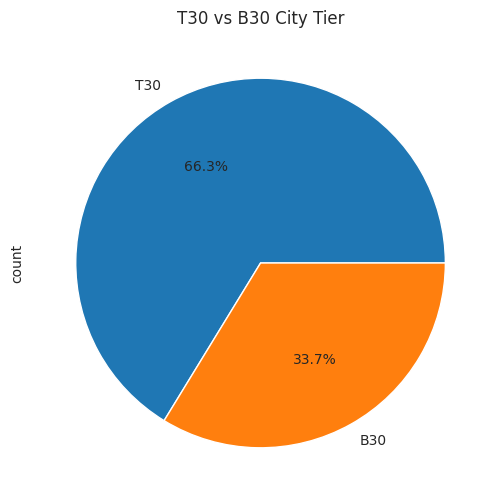

In [25]:
investor["city_tier"].value_counts().plot.pie(
    autopct="%1.1f%%",
)

plt.title("T30 vs B30 City Tier")



---



# **Folio count growth**

The folio count increased significantly from 13.26 crore (January 2022) to 26.12 crore (December 2025), indicating a substantial rise in retail investor participation and growing confidence in the mutual fund industry.

In [15]:
fix = px.line(
    folios,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Folio Count Growth (Jan 2022 – Dec 2025)"
)

fig.add_annotation(
    x="2022-01-01",
    y=13.26,
    text="13.26 Cr"
)

fig.add_annotation(
    x="2025-12-01",
    y=26.12,
    text="26.12 Cr"
)

fig.show()



---



# **NAV Return Correlation**

The correlation heatmap shows that several equity funds have a strong positive correlation, meaning they tend to move in the same direction under similar market conditions. Funds with lower correlations offer better diversification benefits and can help reduce overall portfolio risk.

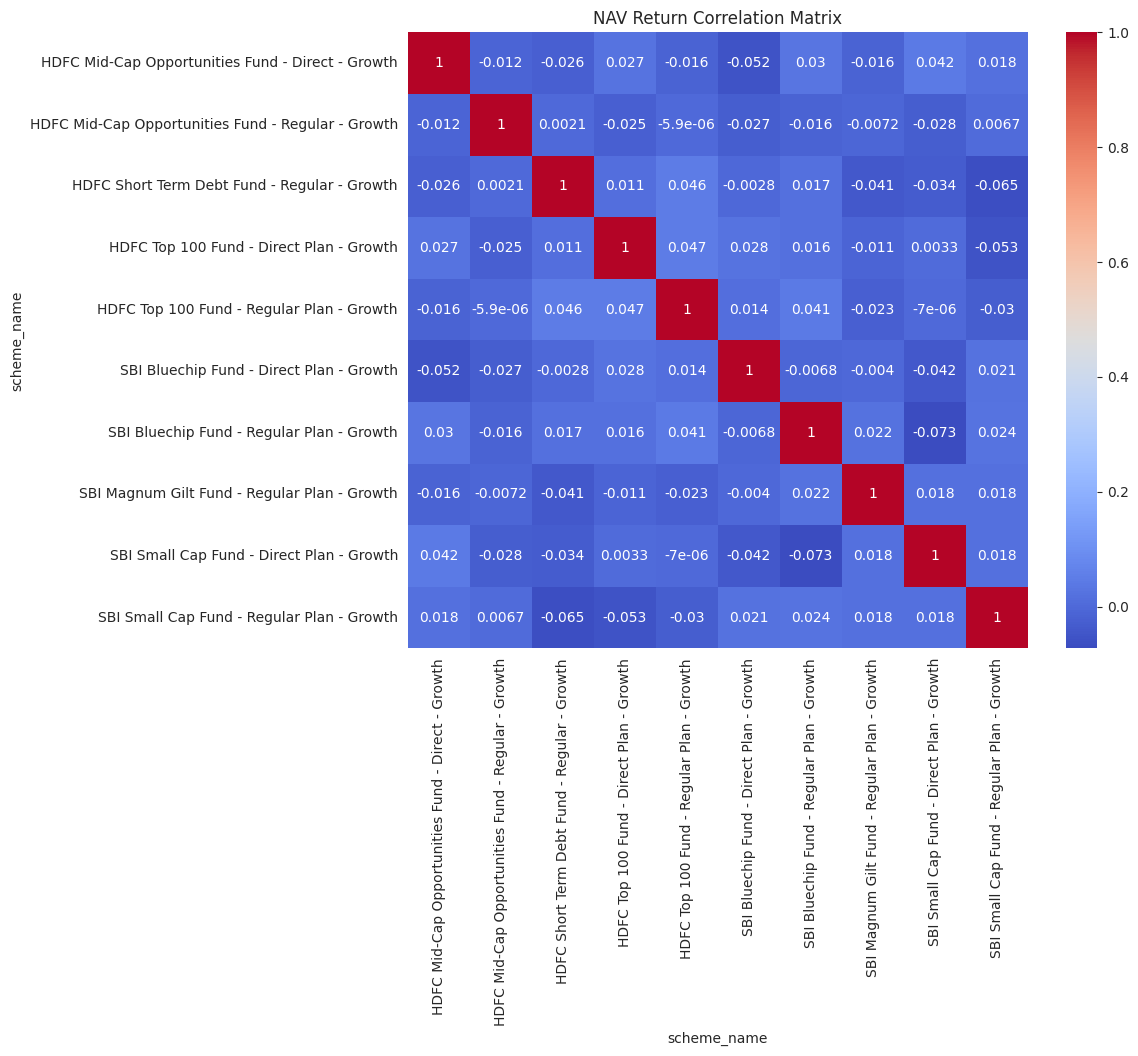

In [29]:
top10=nav_df["scheme_name"].unique()[:10]

corr=nav_df[
    nav_df["scheme_name"].isin(top10)
]

corr=corr.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)

returns=corr.pct_change()

plt.figure(figsize=(10,8))

sns.heatmap(
    returns.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")

plt.show()



---



# **Sector Allocation Donut**

The analysis shows that sectors such as Financial Services, Information Technology, Banking, and Healthcare hold the largest share of portfolio allocations, indicating that fund managers primarily invest in sectors with strong growth potential and market significance.

In [18]:
sector = portfolio.groupby ("sector")["weight_pct"].sum()

fig = px.pie (
    values=sector.values,
    names=sector.index,
    title="Sector Allocation",
    hole=0.5
)

fig.show()



---



# **Top Fund Houses**

The analysis shows that SBI Mutual Fund has the highest AUM, making it the market leader among fund houses. Other leading fund houses also manage substantial assets, reflecting strong investor trust and a competitive mutual fund industry.

Text(0.5, 1.0, 'Top Fund Houses')

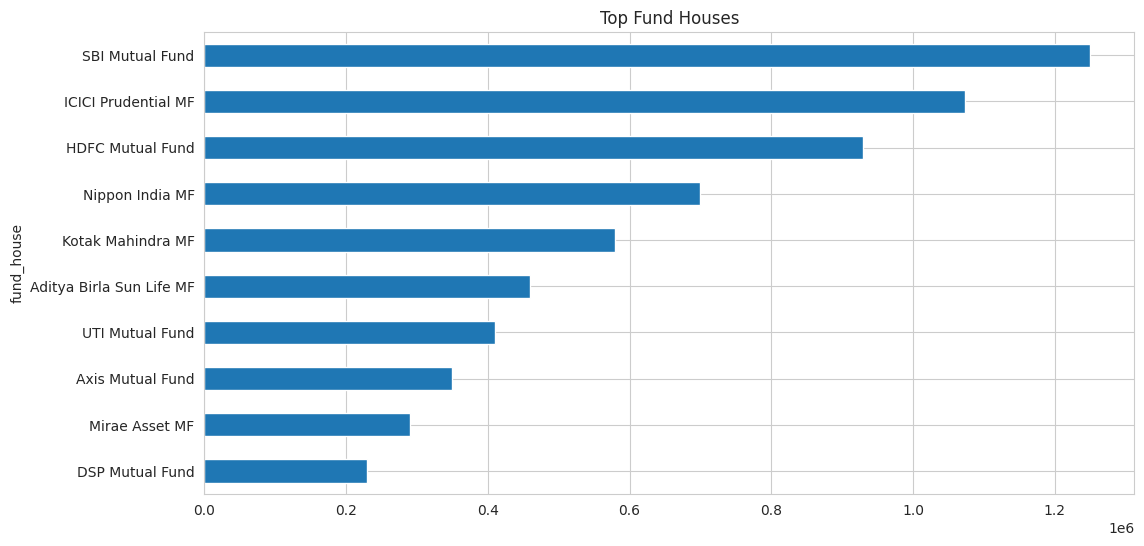

In [30]:
top = aum.groupby("fund_house")["aum_crore"].max().sort_values()

top.plot.barh()

plt.title("Top Fund Houses")

# **Risk vs Return**

The scatter plot reveals that high-return funds often exhibit greater volatility. However, a few funds achieve above-average returns with moderate risk, indicating efficient portfolio management and better risk-adjusted performance.



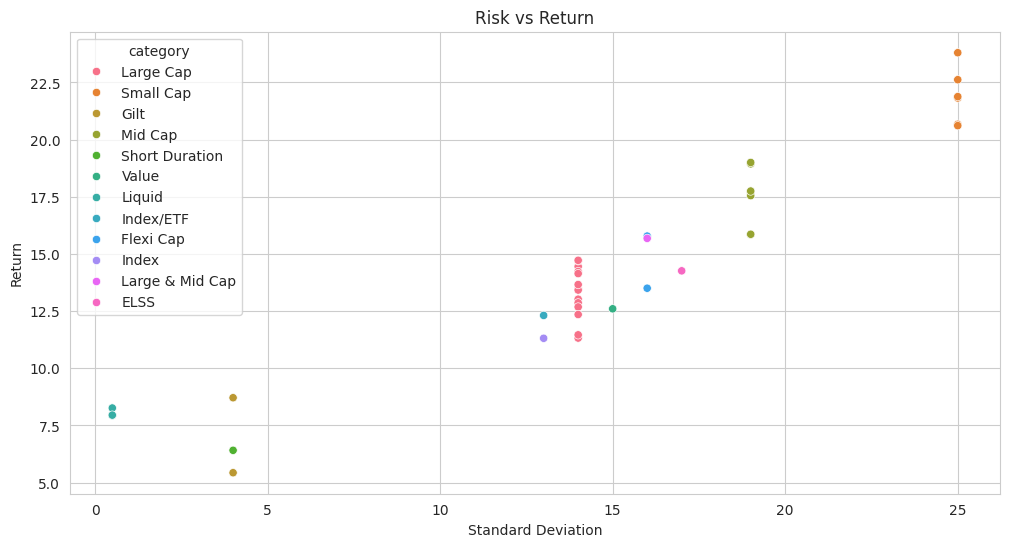

In [32]:
sns.scatterplot(
    data=performance,
    x="std_dev_ann_pct",
    y="return_5yr_pct",
    hue="category"
)

plt.title("Risk vs Return")
plt.xlabel("Standard Deviation")
plt.ylabel("Return")

plt.show()



---



# **Top Performing Funds**

The analysis highlights the top-performing mutual funds that generated the highest returns during the analysis period. These funds demonstrated strong and consistent performance, making them attractive options for investors seeking long-term wealth creation.

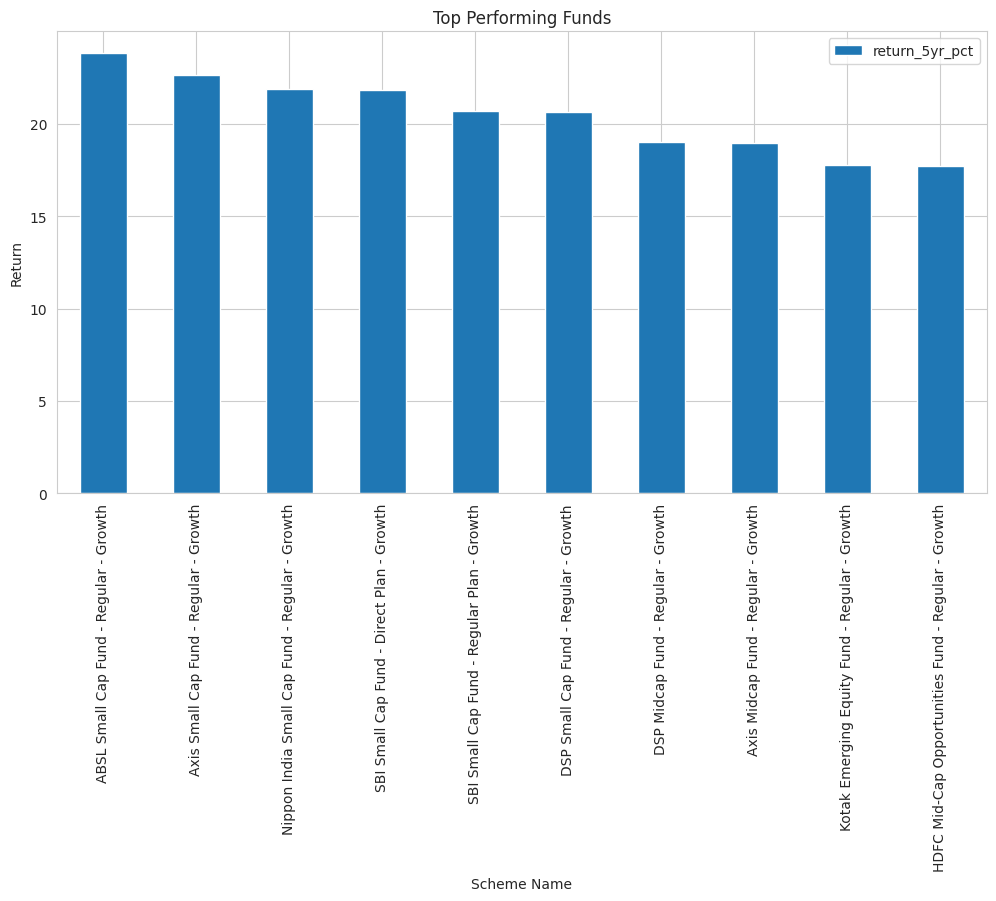

In [34]:
performance.sort_values("return_5yr_pct",ascending=False).head(10).plot.bar(
    x="scheme_name",
    y="return_5yr_pct"
)

plt.title("Top Performing Funds")
plt.xlabel("Scheme Name")
plt.ylabel("Return")

plt.show()